### This is the prompt chaining workflow. 
Where we are calling the LLM multiple times.

Here we will take the topic from the user and ask LLM to create an outline, once the outline is done we will ask thd LLM to crete an blog content for the same outline

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

model = ChatOpenAI()

In [30]:
# defining the state of the graph 
class Blog_state(TypedDict):
    title: str 
    outline: str 
    content: str 

In [31]:
# define the create_outline function 

def create_outline(state: Blog_state) -> Blog_state:

    # fetch the title 
    title = state['title']
    # generate the outline by calling the LLM
    prompt = f"Generate a detail outline for the blog on given topic- {title}"
    outline = model.invoke(prompt).content
    # update the return the state 
    state['outline'] = outline

    return state 

In [32]:
# defining the create blog logic 
def create_blog(state: Blog_state) -> Blog_state:

    # title and the outline is required
    title = state['title']
    outline = state['outline']

    # prompt
    prompt = f"Generate the detailed blog on the given topec -{title} using following outline \n {outline}"

    content = model.invoke(prompt).content

    # update the state 
    state['content'] = content 

    return state

In [33]:
# definning the grpah 
graph = StateGraph(Blog_state)

# adding the node1 to the graph 
graph.add_node("create_outline",create_outline)

# adding the node-2 to the graph 
graph.add_node("create_blog",create_blog)  # while codign remember i have define graph and added the nodes first 
                                            # so the skeleton is defined now and then build the functions 

# once the function are created and the graph is states add the edges 
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)

In [34]:
# compile the graph 
workflow = graph.compile()

In [35]:
# once graph is compile try generating the blog 
initial_state = {"title":"Rise of AI in India"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': 'I. Introduction\n   A. Brief overview of AI\n   B. Introduction to the rise of AI in India\n   \nII. Historical perspective of AI in India\n   A. Early developments in AI in India\n   B. Adoption of AI technologies in various sectors in India\n\nIII. Current landscape of AI in India\n   A. Major players in the AI industry in India\n   B. Growth of AI startups in India\n   C. Government support and initiatives for AI in India\n\nIV. Application of AI in different sectors in India\n   A. Healthcare\n   B. Finance\n   C. Agriculture\n   D. Education\n   E. Manufacturing\n\nV. Challenges and opportunities for AI in India\n   A. Challenges in adoption of AI technologies\n   B. Skill development and talent availability in AI \n   C. Ethical considerations in AI deployment\n   D. Opportunities for AI in India\n   \nVI. Future of AI in India\n   A. Predictions for the growth of AI in India\n   B. Potential impact of AI on the Indian economy\n   C. R

In [23]:
print(final_state['outline'].content)


I. Introduction
    A. Brief overview of artificial intelligence (AI)
    B. Introduction to the rise of AI in India
    C. Importance and impact of AI in various sectors

II. Current Scenario of AI in India
    A. Growth of AI startups in India
    B. Investments in AI technologies in India
    C. Adoption of AI in Indian businesses and industries

III. Government Initiatives and Policies
    A. Government support for the development of AI in India
    B. National AI strategy and policies
    C. Collaboration between government, academia, and industry in promoting AI

IV. Challenges and Opportunities
    A. Challenges faced by AI in India
    B. Opportunities for AI growth in India
    C. Potential for AI to address societal issues in India

V. Impact of AI on Indian Economy
    A. Contribution of AI to the Indian economy
    B. Job creation and skill development in the AI industry
    C. Potential economic benefits of AI in India

VI. Future of AI in India
    A. Predictions and tren

In [36]:
print(final_state['content'])

Artificial Intelligence, or AI, is a rapidly developing field that has the potential to revolutionize various sectors and industries around the world. In recent years, India has emerged as a key player in the global AI market, with significant advancements and investments in this technology. In this blog, we will explore the rise of AI in India, looking at its historical perspective, current landscape, application in different sectors, challenges and opportunities, and the future of AI in the country.

I. Introduction

A. Brief overview of AI: AI refers to the simulation of human intelligence processes by machines, including learning, reasoning, problem-solving, perception, and language understanding.

B. Introduction to the rise of AI in India: India has been increasingly embracing AI technologies in recent years, with a growing number of startups and established companies investing in research and development in this field.

II. Historical perspective of AI in India

A. Early develop

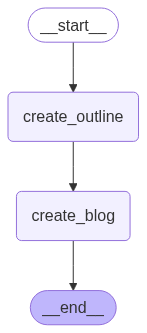

In [9]:
# Visualize the image 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [29]:
print(final_state['content'])

KeyError: 'content'